# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Oluwademilade Subair
**Student ID:** 58742028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.


---

### Part 0: Repository Setup _(done outside this notebook)_

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.


In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import display, Math

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.ensemble import RandomForestClassifier
import time

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---

# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can _plot everything_ — the data, the model's prediction,
and the loss going down.


### Part 1.1 — A single neuron is just a line

A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.


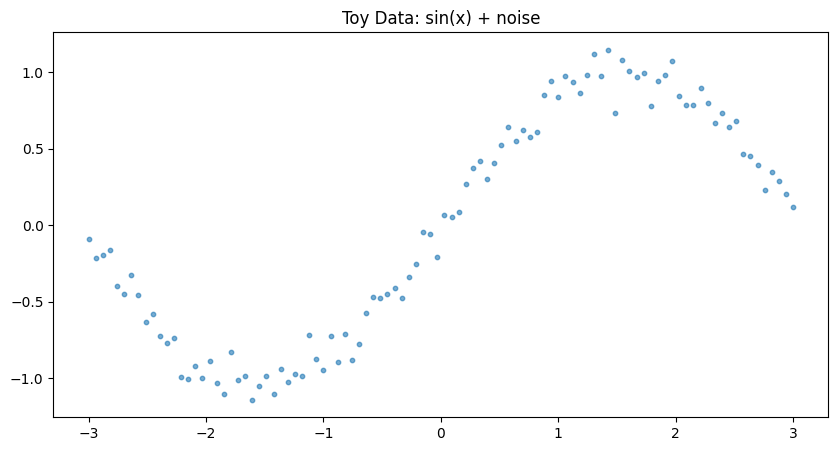

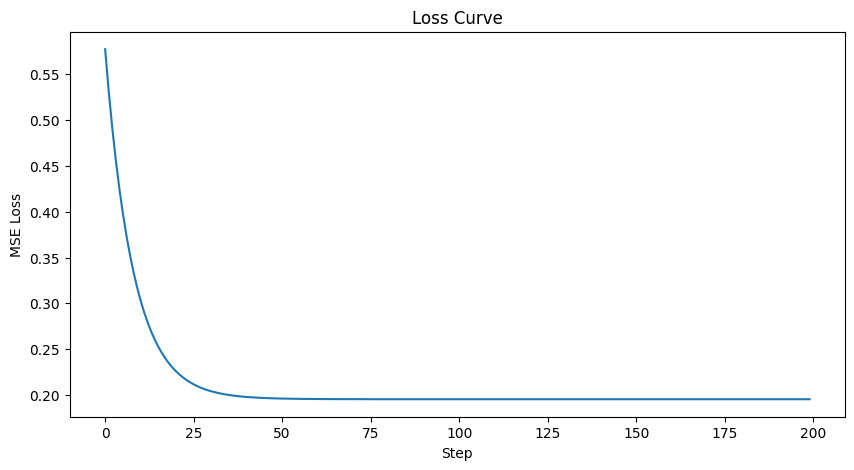

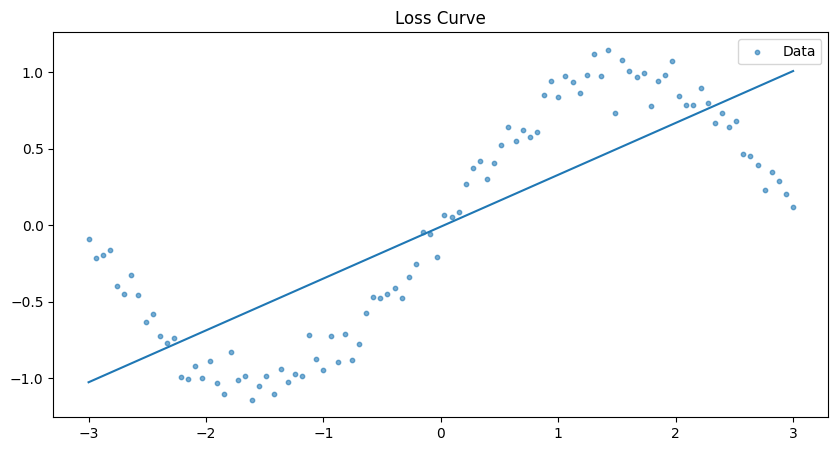

In [2]:
# Generating the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)  # gaussian noise

# Plotting it
plt.figure(figsize=(10, 5))
plt.scatter(x, y, s=10, alpha=0.6)
plt.title("Toy Data: sin(x) + noise")
plt.show()

# Initialise w and b to small random values.
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01
lr = 0.01
losses = []

# Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
for i in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)  # MSE
    dw = np.mean(2 * (y_hat - y) * x)  # dLoss/dw
    db = np.mean(2 * (y_hat - y))  # dLoss/db
    w -= lr * dw
    b -= lr * db
    losses.append(loss)

# Plot the loss curve over the 200 steps
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

# Plot the data with the fitted line on top
plt.figure(figsize=(10, 5))
plt.scatter(x, y, s=10, alpha=0.6, label="Data")
plt.plot(x, w * x + b)
plt.title("Loss Curve")
plt.legend()
plt.show()

**Student Reasoning — The single neuron**
_1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?_
_2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?_

> **Answer:**
> $$L = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

$$\frac{dL}{dw} = \frac{1}{n} \sum_{i=1}^{n} 2(\hat{y}_i - y_i) \cdot {d \hat{y}_i}({\ wx_i + b})$$

since, w and b are constants

$$\frac{dL}{dw} = \frac{1}{n} \sum_{i}^{n} 2(\hat{y}_i - y_i) \cdot x_i$$

Same as code

- This is a clear case of underfitting. This is a single neuron with no activation function for non-linearity, meanwhile it's supposed to fit a non-linear wave. No matter the weights or training, a straight line can never contain the true function of a sine wave.


### Part 1.2 — Hidden layers and activations: why depth helps

Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.


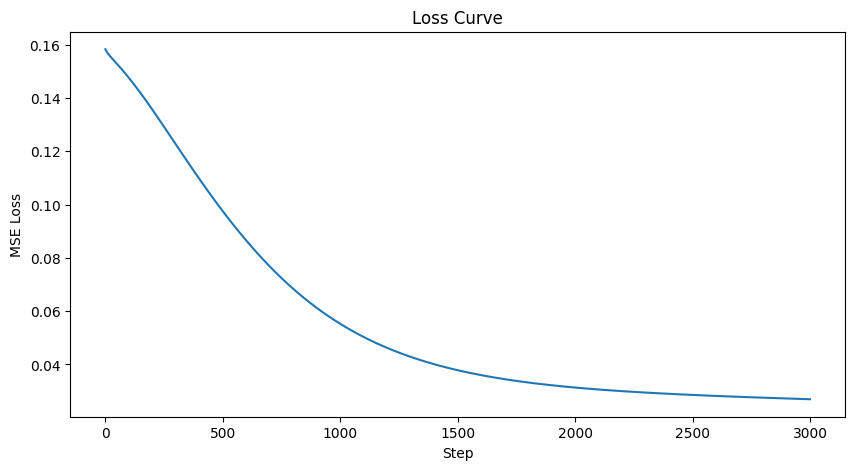

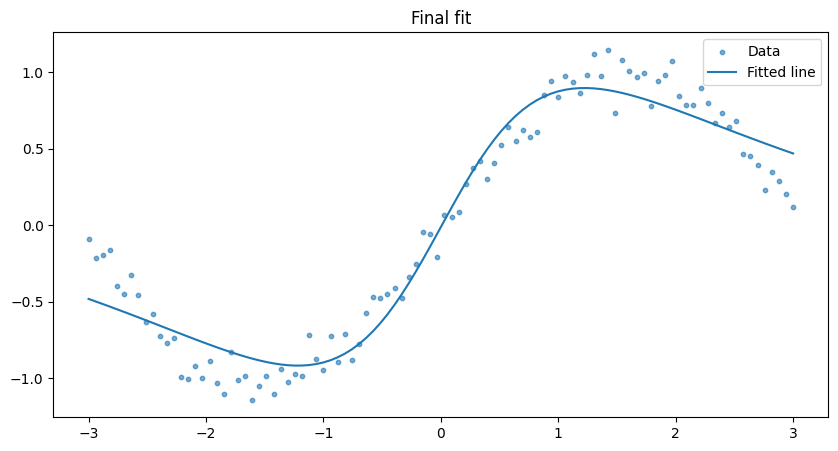

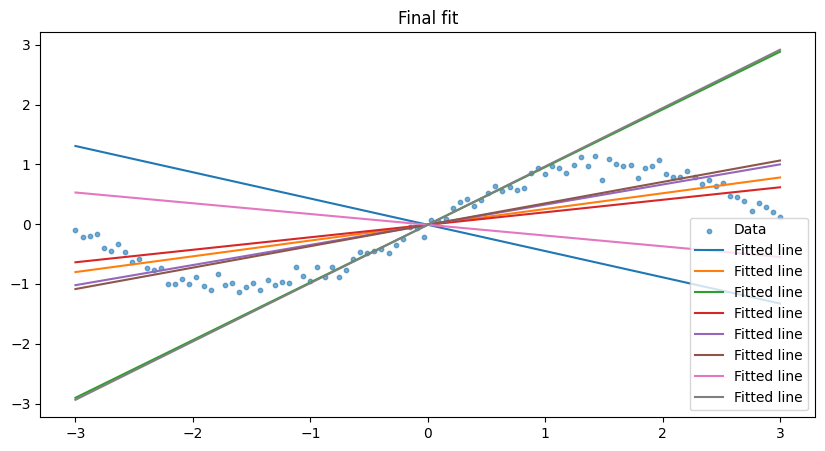

In [3]:
# Initialise parameters with small random values
W1 = np.random.rand(1, 8) * 0.5
b1 = np.zeros(8)
W2 = np.random.rand(8, 1) * 0.5
b2 = np.zeros(1)

lr = 0.01
losses = []
# Reshape x and y to be column vectors
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

# Update all parameters with learning rate lr, loop for ~3000 steps, record the loss.
for i in range(3000):
    # Forward pass (keep the intermediate values, need them for backprop):
    z1 = x @ W1 + b1  # pre-activation, shape (100, 8)
    h = np.tanh(z1)  # activation
    y_hat = h @ W2 + b2  # output, shape (100, 1)
    loss = np.mean((y_hat - y) ** 2)

    # Backward pass (the chain rule, layer by layer):
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)  # derivative of tanh
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    losses.append(loss)

# Plot the loss curve AND the final fit over the data
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(x, y, s=10, alpha=0.6, label="Data")
plt.plot(x, np.tanh(x @ W1 + b1) @ W2 + b2, label="Fitted line")
plt.title("Final fit")
plt.legend()
plt.show()

lossesRemoved = []
# Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
for i in range(3000):
    # Forward pass (keep the intermediate values, need them for backprop):
    z1 = x @ W1 + b1  # pre-activation, shape (100, 8)
    h = z1  # no activation
    y_hat = h @ W2 + b2  # output, shape (100, 1)
    lossR = np.mean((y_hat - y) ** 2)

    # Backward pass (the chain rule, layer by layer):
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh  # derivate of linear h is 1
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    lossesRemoved.append(lossR)

# Plot the final fit over the data
plt.figure(figsize=(10, 5))
plt.scatter(x, y, s=10, alpha=0.6, label="Data")
plt.plot(x, x @ W1 + b1 @ W2 + b2, label="Fitted line")
plt.title("Final fit")
plt.legend()
plt.show()

**Student Reasoning — Depth and activations**
_1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer._
_2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)_
_3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?_

> **Answer:**

- W2(W1x + b1) + b2 = (W2W1)x + (W2b1 + b2). W2W1 is another matrix, hence all the biases collapse into one. Hence, there'll just be a single LINEAR transformation that doesn't break linearity (remains linear), as seen, when tanh is removed.
- The input each neuron brings a shifted version of tanh, produving the S-shaped curve. They're basically flexible non-linear functions combined to fit sin x. The output layer then takes a weighted sum of all 8 neurons to approximate.
- Feeding the loss/error from each weight (and how much it contributed) back through every parameter in the neuron for correction


### Part 1.3 — The learning rate: too cold, too hot, just right

The single most important hyperparameter. See its three regimes with your own eyes.


c:\Users\Demilade Subair\OneDrive - Ashesi University\2nd year\2nd Semester\Intro to AI\sandbox\Demi-CS254\ai_labs\ai_env\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\Demilade Subair\AppData\Local\Temp\ipykernel_29856\3639779765.py:16: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
C:\Users\Demilade Subair\AppData\Local\Temp\ipykernel_29856\3639779765.py:22: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
C:\Users\Demilade Subair\AppData\Local\Temp\ipykernel_29856\3639779765.py:23: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)  # derivative of tanh
c:\Users\Demilade Subair\OneDrive - Ashesi University\2nd year\2nd Semester\Intro to AI\sandbox\Demi-CS254\ai_labs\ai_env\Lib\site-packages\matplotlib\scale.py:270: RuntimeWarning: overflow encountered in power
  return np.pow

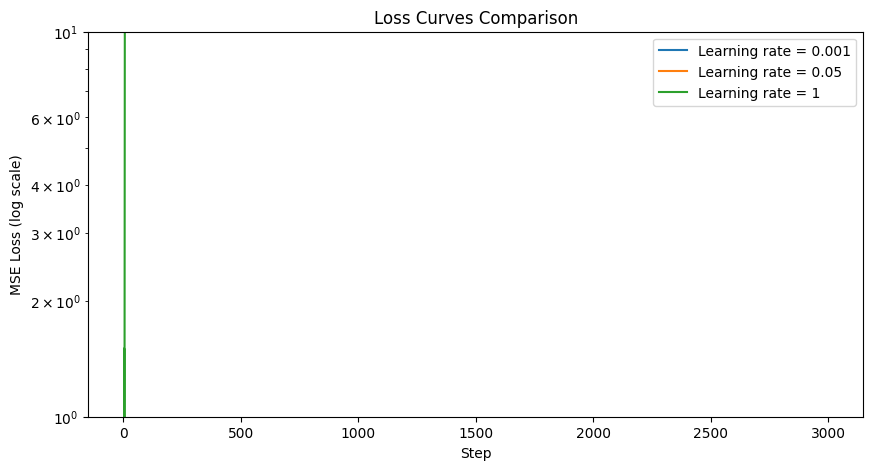

lr=0.001 final loss: 0.12261072354977447
lr=0.05 final loss: 0.015639006752111453
lr=1.0 final loss: nan


In [4]:
# Wrap Part 1.2 training loop in a function train_toy(lr, steps=3000) that returns the list of losses.
def train_toy(lr, steps=3000):
    # Initialise parameters with small random values
    W1 = np.random.rand(1, 8) * 0.5
    b1 = np.zeros(8)
    W2 = np.random.rand(8, 1) * 0.5
    b2 = np.zeros(1)

    losses = []

    for i in range(steps):
        # Forward pass (keep the intermediate values, need them for backprop):
        z1 = x @ W1 + b1  # pre-activation
        h = np.tanh(z1)  # activation
        y_hat = h @ W2 + b2  # output
        loss = np.mean((y_hat - y) ** 2)

        # Backward pass (the chain rule, layer by layer):
        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)  # derivative of tanh
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

        losses.append(loss)

    return losses


# Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
# (with the same initial weights for a fair comparison & reset the seed).
np.random.seed(RANDOM_STATE)
losses0001 = train_toy(0.001, 3000)

np.random.seed(RANDOM_STATE)
losses005 = train_toy(0.05, 3000)

np.random.seed(RANDOM_STATE)
losses1 = train_toy(1.0, 3000)

# Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(10, 5))
plt.plot(losses0001, label="Learning rate = 0.001")
plt.plot(losses005, label="Learning rate = 0.05")
plt.plot(losses1, label="Learning rate = 1")
plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("MSE Loss (log scale)")
plt.title("Loss Curves Comparison")
plt.legend()
plt.show()

print(f"lr=0.001 final loss: {losses0001[-1]}")
print(f"lr=0.05 final loss: {losses005[-1]}")
print(f"lr=1.0 final loss: {losses1[-1]}")

**Student Reasoning — Learning rate**
_Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?_

> **Answer:**

- A too-large learning rate caused the gradient to explode. Instead of gradually approaching the bottom of the loss curve, it steps past it and lands somewhere even worse, before overshooting again in the other direction, leading it to explode to NaN within a few steps. The other learning rates are likely flat because they do not compare to `lr=1`'s explosion, making them invisible on the same scale. However, `lr = 0.05` had only a loss of 0.016, which is kind of okay but `lr = 0.001` learned too slowly in 3000 steps, so it needs more steps to converge after a loss of 0.12


---

# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.


### Part 2.1 — Preprocess and split (recycled from Lab 2)

Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.


In [5]:
# Load the obesity dataset (same OBESITY_URL as Lab 2)
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)

# Encode categoricals exactly as done in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
obesity[binary_cols] = obesity[binary_cols].apply(
    lambda col: col.map({"yes": 1, "no": 0})
)

caec_ord = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
calc_ord = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}

obesity["CAEC"] = obesity["CAEC"].map(caec_ord)
obesity["CALC"] = obesity["CALC"].map(calc_ord)

# No order
obesity = pd.get_dummies(obesity, columns=["Gender"])
obesity = pd.get_dummies(obesity, columns=["MTRANS"])

# Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
le = LabelEncoder()
obesity["NObeyesdad"] = le.fit_transform(obesity["NObeyesdad"])
class_names = le.classes_

# Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X = obesity.drop(columns=["NObeyesdad"])
y = obesity["NObeyesdad"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

# Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to tensors and wrap in DataLoaders:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# train_loader (batch_size=32, shuffle=True), val_loader, test_loader
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True
)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32)

**Student Reasoning — Preprocessing for neural networks**
_1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?_
_2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1._
_3. What does `shuffle=True` on the training DataLoader do, and why does it help?_

> **Answer:**

- CrossEntropyLoss applies softmax and expects a raw class index so it can index the output for that class. A one-hot vector will require extra matrix multiplication
- `dW1 = x.T @ dz1` means the gradient of the first layer's weights is directly scaled by the x. If one feature has values in thousands and another has between 0-1, the gradients connected to the larger feature will be huge and tiny for the small feature. Whereas, random forst split on thresholds so the scale doesn't affect whatever split, only order
- It reshuffles the training data into different random batches so that the model never sees the same batch ordering twice. This prevents overfitting to sequence of examples and helps with regularisation by introducing noise


### Part 2.2 — Design the network

An MLP: input -> hidden layers with ReLU -> 7 output logits.


In [6]:
# Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)


class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()
        layers = []
        input_dimension = input_dim
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_dimension, hidden_size))
            layers.append(nn.ReLU())
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))
            input_dimension = hidden_size
        layers.append(nn.Linear(input_dimension, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# Instantiate, move to DEVICE, print the model.
input_dim = X_train.shape[1]
model = FeedForwardNet(input_dim).to(DEVICE)
print(model)

# Count trainable parameters:
print(sum(p.numel() for p in model.parameters() if p.requires_grad))
print(input_dim * 64 + 64)  # verifying the count for the first layer

FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
3719
1408


**Student Reasoning — Architecture**
_1. Show the by-hand parameter count for every layer and confirm it matches PyTorch._
_2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage._
_3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)_

> **Answer:**

- fc1: 21 \* 64 + 64 = 1408
- fc2: 64 \* 32 + 32 = 2080
- fc3: 32 \* 7 + 7 = 231
- Total: 3719 (matches PyTorch)

- ReLU's gradient is simply 1 for any positive input whether big or large but tanh has vanishing gradients for larger activations meaning slowing learning.ReLU keeps gradients flowing cleanly through deep netwroks.

- Without ReLUs every layer is just a linear transformation and a stack of linear layers will always give a single linear layer. The networks wouldn't be able to fit the non-linear decision boundaries to separate 7 obesity classes


### Part 2.3 — The training loop

The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.


Epoch 1 | train_loss: 1.7377783060073853 | train_acc: 0.45181673765182495 | val_loss: 1.7396469116210938 | val_acc: 0.45734596252441406
Epoch 2 | train_loss: 1.3399165868759155 | train_acc: 0.5647709369659424 | val_loss: 1.3572728633880615 | val_acc: 0.5568720102310181
Epoch 3 | train_loss: 1.0185438394546509 | train_acc: 0.6753554344177246 | val_loss: 1.0678200721740723 | val_acc: 0.6327013969421387
Epoch 4 | train_loss: 0.8288967609405518 | train_acc: 0.7203791737556458 | val_loss: 0.9277893900871277 | val_acc: 0.6800947785377502
Epoch 5 | train_loss: 0.7081506252288818 | train_acc: 0.7567140460014343 | val_loss: 0.8473355174064636 | val_acc: 0.7203791737556458
Epoch 6 | train_loss: 0.6109206080436707 | train_acc: 0.7969984412193298 | val_loss: 0.7802386283874512 | val_acc: 0.7511848211288452
Epoch 7 | train_loss: 0.5372585654258728 | train_acc: 0.8285939693450928 | val_loss: 0.7337230443954468 | val_acc: 0.7725118398666382
Epoch 8 | train_loss: 0.47593632340431213 | train_acc: 0.857

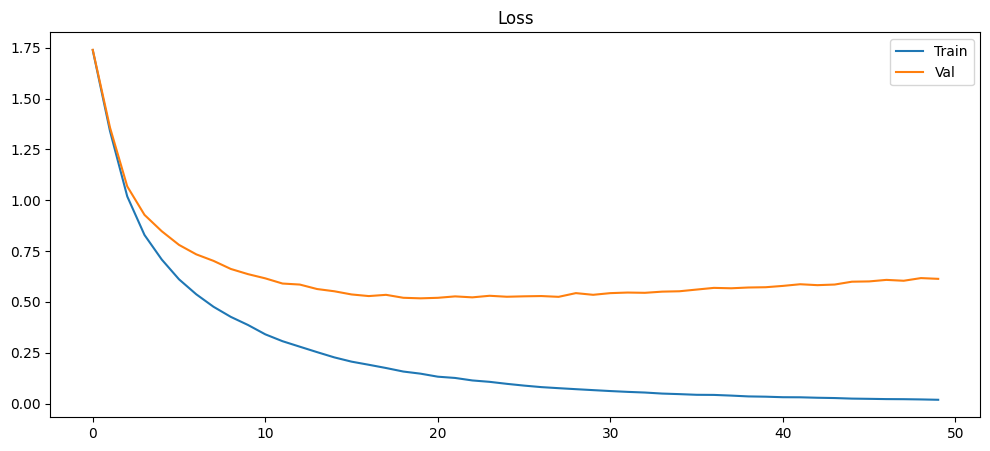

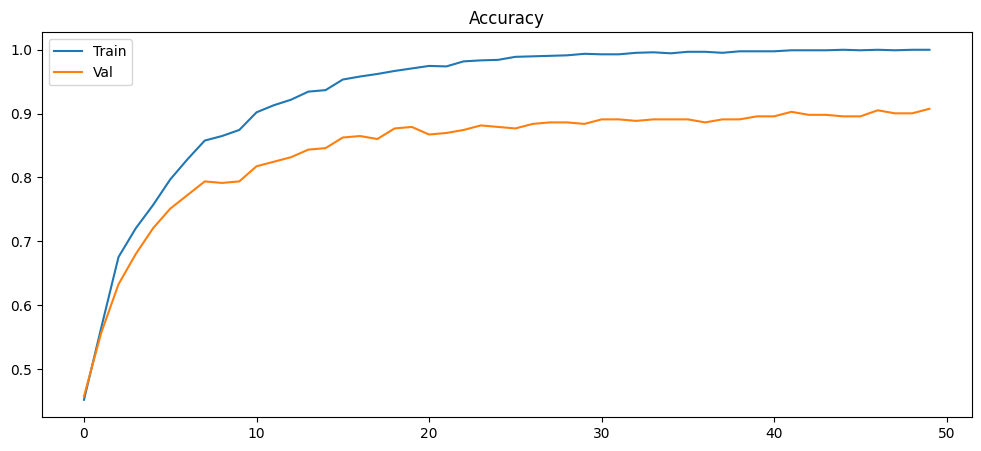

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # or SGD — justify
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_val_acc = 0.0

# Train for at least 50 epochs. Each epoch:
for epoch in range(50):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb.to(DEVICE))
        loss = criterion(logits, yb.to(DEVICE))
        loss.backward()  # <- the backprop wrote in Part 1.2
        optimizer.step()  # <- the update rule wrote in Part 1.1

    model.eval()
    with torch.no_grad():
        train_logits = model(X_train_tensor.to(DEVICE))
        train_loss = criterion(train_logits, y_train_tensor.to(DEVICE)).item()
        train_acc = (
            (train_logits.argmax(1) == y_train_tensor.to(DEVICE)).float().mean().item()
        )

        val_logits = model(X_val_tensor.to(DEVICE))
        val_loss = criterion(val_logits, y_val_tensor.to(DEVICE)).item()
        val_acc = (
            (val_logits.argmax(1) == y_val_tensor.to(DEVICE)).float().mean().item()
        )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # Save the best model (highest validation accuracy):
        torch.save(model.state_dict(), "ffn_best.pt")

    print(
        f"Epoch {epoch + 1} | train_loss: {train_loss} | train_acc: {train_acc} | val_loss: {val_loss} | val_acc: {val_acc}"
    )

# Plot loss curves (train + val) and accuracy curves (train + val), with legends.
plt.figure(figsize=(12, 5))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()

plt.figure(figsize=(12, 5))
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Val")
plt.title("Accuracy")
plt.legend()

plt.show()

**Student Reasoning — Training**
_1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?_
_2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim._
_3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?_

> **Answer:**

- `logits = model(xb)` is the forward pass from `z1 = x @ W1 + b1`, `h = tanh(z1)` & `y_hat = h @ W2 + b2`
- `loss.backward()` is the backward pass from the chain rule: `dW1`, `dW2`, `db1`, `db2`
- `optimizer.step()` is the update rule `Wn -= lr * dWn`
- `optimizer.zero_grad()` is the the reset that didn't before since we computed gradients fresh each step
- There is overfitting, from epoch 20 onwards train loss drops toward 0.02 while val loss starts increasing to 0.59. The train accuracy hits 100% since epoch 1, while val loss climbs to 91%, a rather consistent graph through the second half of epochs. The model memorised the training set and the increasing loss curve between training and val confirm it
- Gradients are accumulated by default, hence every `loss.backward()` sums up gradients already stored rather than replacing them. Without zeroing with `optimizer.zero_grad()`, gradients from previous batches stack up and the update steps uses this sum instead of just the current one,, making increasingly large updates


### Part 2.4 — Experiments: how training choices change the outcome

Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.



Training network: (8,)
Epoch 1 | train_loss: 1.8951319456100464 | train_acc: 0.2890995144844055 | val_loss: 1.8892496824264526 | val_acc: 0.27014216780662537
Epoch 2 | train_loss: 1.8222466707229614 | train_acc: 0.39573460817337036 | val_loss: 1.817704200744629 | val_acc: 0.39573460817337036
Epoch 3 | train_loss: 1.7404298782348633 | train_acc: 0.42259085178375244 | val_loss: 1.7396434545516968 | val_acc: 0.41706159710884094
Epoch 4 | train_loss: 1.6471188068389893 | train_acc: 0.43680885434150696 | val_loss: 1.650996446609497 | val_acc: 0.4597156345844269
Epoch 5 | train_loss: 1.5498043298721313 | train_acc: 0.4628751873970032 | val_loss: 1.558355450630188 | val_acc: 0.48104265332221985
Epoch 6 | train_loss: 1.4558385610580444 | train_acc: 0.4849920868873596 | val_loss: 1.466447114944458 | val_acc: 0.5047393441200256
Epoch 7 | train_loss: 1.3733916282653809 | train_acc: 0.4936808943748474 | val_loss: 1.3862090110778809 | val_acc: 0.5142180323600769
Epoch 8 | train_loss: 1.30367088317

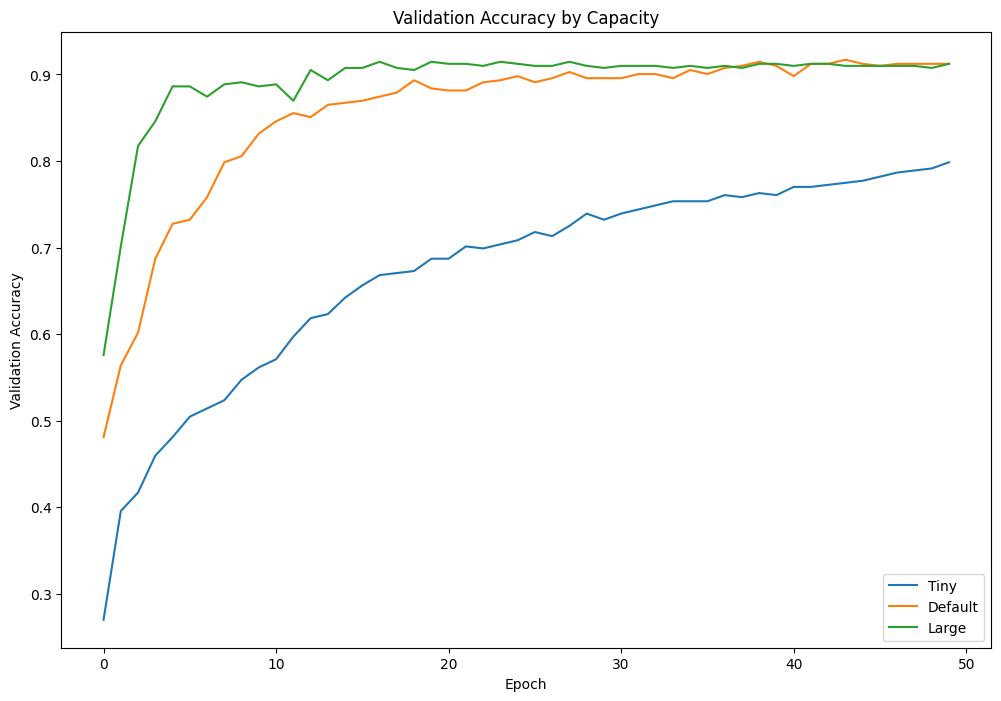


Training network: (64, 32)
Epoch 1 | train_loss: 1.954045057296753 | train_acc: 0.14454975724220276 | val_loss: 1.9530692100524902 | val_acc: 0.14454975724220276
Epoch 2 | train_loss: 1.9387538433074951 | train_acc: 0.1579778790473938 | val_loss: 1.938205361366272 | val_acc: 0.15876777470111847
Epoch 3 | train_loss: 1.923548936843872 | train_acc: 0.18009479343891144 | val_loss: 1.923690915107727 | val_acc: 0.19194312393665314
Epoch 4 | train_loss: 1.9075989723205566 | train_acc: 0.21169036626815796 | val_loss: 1.9086580276489258 | val_acc: 0.21800947189331055
Epoch 5 | train_loss: 1.8899221420288086 | train_acc: 0.25039494037628174 | val_loss: 1.8918099403381348 | val_acc: 0.25592416524887085
Epoch 6 | train_loss: 1.8708584308624268 | train_acc: 0.2725118398666382 | val_loss: 1.8733751773834229 | val_acc: 0.2725118398666382
Epoch 7 | train_loss: 1.8489593267440796 | train_acc: 0.30015796422958374 | val_loss: 1.8520771265029907 | val_acc: 0.29146918654441833
Epoch 8 | train_loss: 1.824

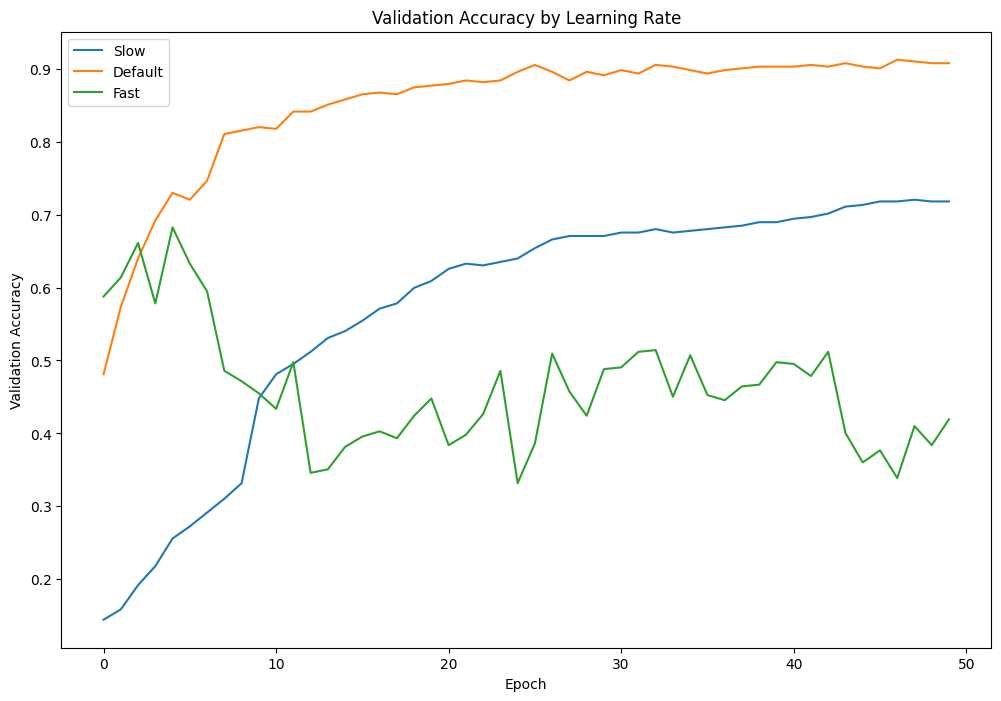


Training network: (256, 128, 64)
Epoch 1 | train_loss: 1.0515962839126587 | train_acc: 0.6129541993141174 | val_loss: 1.1026506423950195 | val_acc: 0.5900474190711975
Epoch 2 | train_loss: 0.6472977995872498 | train_acc: 0.7590837478637695 | val_loss: 0.7323164343833923 | val_acc: 0.7274881601333618
Epoch 3 | train_loss: 0.3805154263973236 | train_acc: 0.8981042504310608 | val_loss: 0.5538896918296814 | val_acc: 0.8364928960800171
Epoch 4 | train_loss: 0.24880728125572205 | train_acc: 0.9352290630340576 | val_loss: 0.4913516640663147 | val_acc: 0.8815165758132935
Epoch 5 | train_loss: 0.20496925711631775 | train_acc: 0.9368088245391846 | val_loss: 0.4813835322856903 | val_acc: 0.8601895570755005
Epoch 6 | train_loss: 0.13342022895812988 | train_acc: 0.9691942930221558 | val_loss: 0.44067758321762085 | val_acc: 0.9028435945510864
Epoch 7 | train_loss: 0.10758236795663834 | train_acc: 0.9731437563896179 | val_loss: 0.5015949606895447 | val_acc: 0.8886256217956543
Epoch 8 | train_loss: 0

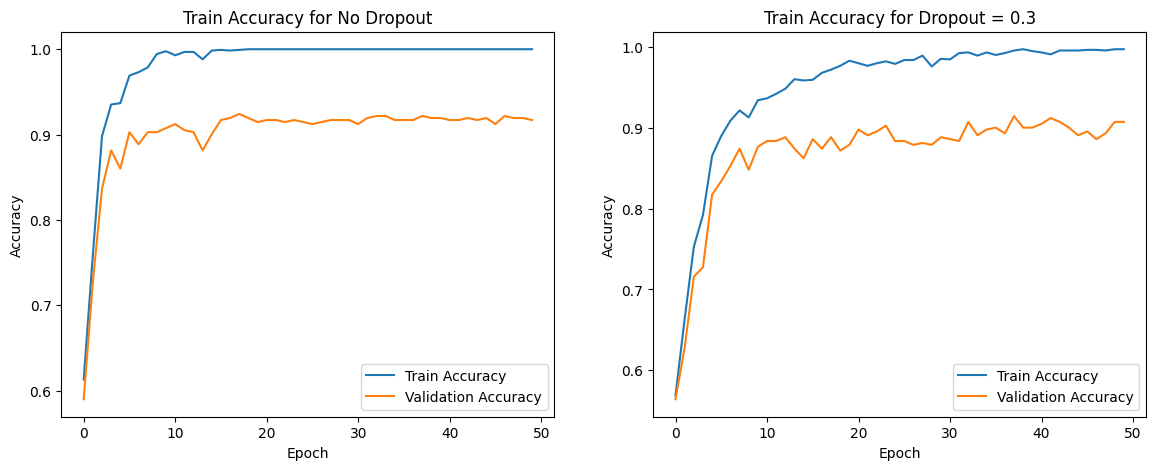

In [ ]:
# Wrap Part 2.3 loop in a function first:
def run_experiment(
    hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0
):
    model = FeedForwardNet(input_dim, hidden_sizes=hidden_sizes, dropout=dropout).to(
        DEVICE
    )
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history_dict = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    best_val_acc = 0.0

    print(f"\nTraining network: {hidden_sizes}")
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb.to(DEVICE))
            loss = criterion(logits, yb.to(DEVICE))
            loss.backward()  # <- the backprop wrote in Part 1.2
            optimizer.step()  # <- the update rule wrote in Part 1.1

        model.eval()
        with torch.no_grad():
            train_logits = model(X_train_tensor.to(DEVICE))
            train_loss = criterion(train_logits, y_train_tensor.to(DEVICE)).item()
            train_acc = (
                (train_logits.argmax(1) == y_train_tensor.to(DEVICE))
                .float()
                .mean()
                .item()
            )

            val_logits = model(X_val_tensor.to(DEVICE))
            val_loss = criterion(val_logits, y_val_tensor.to(DEVICE)).item()
            val_acc = (
                (val_logits.argmax(1) == y_val_tensor.to(DEVICE)).float().mean().item()
            )

        history_dict["train_loss"].append(train_loss)
        history_dict["train_acc"].append(train_acc)
        history_dict["val_loss"].append(val_loss)
        history_dict["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            # Save the best model (highest validation accuracy):
            torch.save(
                model.state_dict(),
                f"ffn_best_{'_'.join(map(str, hidden_sizes))}_dropout{dropout}.pt",
            )

        print(
            f"Epoch {epoch + 1} | train_loss: {train_loss} | train_acc: {train_acc} | val_loss: {val_loss} | val_acc: {val_acc}"
        )
    return history_dict


# Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
tiny = run_experiment(hidden_sizes=(8,))
default = run_experiment(hidden_sizes=(64, 32))
large = run_experiment(hidden_sizes=(256, 128, 64))

# Plot the three validation-accuracy curves together.

plt.figure(figsize=(12, 8))

plt.title("Validation Accuracy by Capacity")
plt.plot(tiny["val_acc"], label="Tiny")
plt.plot(default["val_acc"], label="Default")
plt.plot(large["val_acc"], label="Large")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.show()

# Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
# Plot the three validation-loss curves together. Compare with Part 1.3.
lr_slow = run_experiment(lr=1e-4)
lr_default = run_experiment(lr=1e-3)
lr_fast = run_experiment(lr=1e-1)

plt.figure(figsize=(12, 8))

plt.title("Validation Accuracy by Learning Rate")
plt.plot(lr_slow["val_acc"], label="Slow")
plt.plot(lr_default["val_acc"], label="Default")
plt.plot(lr_fast["val_acc"], label="Fast")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.show()

# Experiment C (regularization): take your LARGEST network and train it with and without nn.Dropout(0.3) after each hidden layer.
no_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0)
with_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3)

#   Plot train vs validation accuracy for both runs.
plt.subplots(1, 2, figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.title("Train Accuracy for No Dropout")
plt.plot(no_dropout["train_acc"], label="Train Accuracy")
plt.plot(no_dropout["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.title("Train Accuracy for Dropout = 0.3")
plt.plot(with_dropout["train_acc"], label="Train Accuracy")
plt.plot(with_dropout["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

**Student Reasoning — Experiments**
_1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?_
_2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?_
_3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this._

> **Answer:**

- Capacity: The largest network won and had higher validation accurancy. There is no overfitting as all three converge without the validation accuracy dropping. Diminishing returns are visible between Default and Large networks as they both reached 92%.
- Learning rate: It matches as the toy problem also showed slow convergence for small lr, clean descent for good lr and diverging loss for large lr.
- Regularization: No droupout showed clear overfitting as train accuracy shows 100% but val peaks at 91% but without dropout the gap reduced as the curves stay closes together longer during earlier epochs. Dropout achieves this by randomnly disabling 30% of neurons during each training step, forcing the network to not rely on any single neuron, training it on different networks and learn more redundant representations to reduce memorisation.


### Part 2.5 — Final evaluation and showdown with Lab 2

One honest number on the test set — then compare with your classical models.


Test Accuracy: 0.9385342789598109
Macro F1: 0.9363154471287382
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.94      0.96        54
      Normal_Weight       0.82      0.84      0.83        58
     Obesity_Type_I       1.00      0.97      0.99        70
    Obesity_Type_II       0.98      0.97      0.97        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.86      0.83      0.84        58
Overweight_Level_II       0.94      1.00      0.97        58

           accuracy                           0.94       423
          macro avg       0.94      0.94      0.94       423
       weighted avg       0.94      0.94      0.94       423



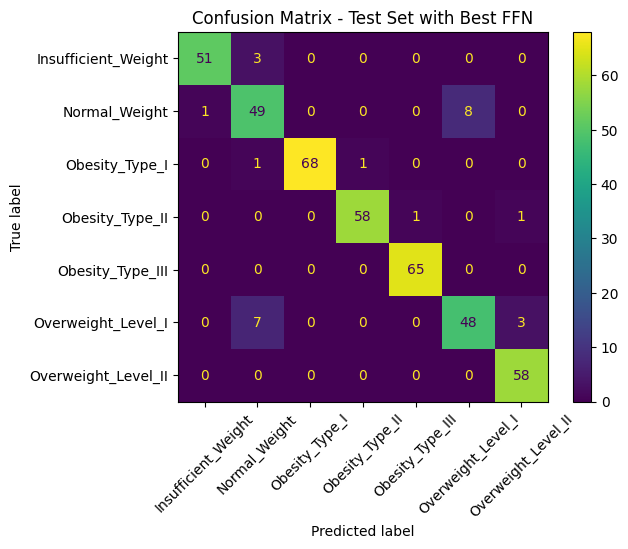


Training network: (256, 128, 64)
Epoch 1 | train_loss: 1.0896800756454468 | train_acc: 0.6429699659347534 | val_loss: 1.146680474281311 | val_acc: 0.5924170613288879
Epoch 2 | train_loss: 0.5906630754470825 | train_acc: 0.7875197529792786 | val_loss: 0.7608093619346619 | val_acc: 0.7274881601333618
Epoch 3 | train_loss: 0.37353092432022095 | train_acc: 0.8941548466682434 | val_loss: 0.6201398968696594 | val_acc: 0.8388625383377075
Epoch 4 | train_loss: 0.23409207165241241 | train_acc: 0.9383886456489563 | val_loss: 0.5055143237113953 | val_acc: 0.8696682453155518
Epoch 5 | train_loss: 0.2179504632949829 | train_acc: 0.9210110306739807 | val_loss: 0.503131628036499 | val_acc: 0.8625592589378357
Epoch 6 | train_loss: 0.12885911762714386 | train_acc: 0.9763033390045166 | val_loss: 0.5065609216690063 | val_acc: 0.8909952640533447
Epoch 7 | train_loss: 0.09837257862091064 | train_acc: 0.9739336371421814 | val_loss: 0.5194428563117981 | val_acc: 0.8957346081733704
Epoch 8 | train_loss: 0.07

In [9]:
# Load your best configuration's weights; model.eval().
best_model = FeedForwardNet(input_dim, hidden_sizes=(256, 128, 64), dropout=0.0).to(
    DEVICE
)
best_model.load_state_dict(torch.load("ffn_best_256_128_64_dropout0.0.pt"))
best_model.eval()

# Report test ACCURACY and MACRO-F1
with torch.no_grad():
    test_logits = best_model(X_test_tensor.to(DEVICE))
    test_preds = test_logits.argmax(1).cpu().numpy()

y_test_np = y_test_tensor.numpy()
print(f"Test Accuracy: {accuracy_score(y_test_np, test_preds)}")
print(f"Macro F1: {f1_score(y_test_np, test_preds, average='macro')}")
print(classification_report(y_test_np, test_preds, target_names=class_names))

# Confusion matrix for the test set with the 7 class names
ConfusionMatrixDisplay.from_predictions(
    y_test_np, test_preds, display_labels=class_names, xticks_rotation=45
)

plt.title("Confusion Matrix - Test Set with Best FFN")
plt.show()

# Build a small comparison table (pandas DataFrame):
#   rows = [best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)

start = time.time()
run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0, epochs=50)
nn_time = time.time() - start

nn_acc = accuracy_score(y_test_np, test_preds)
nn_f1 = f1_score(y_test_np, test_preds, average="macro")

start = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start

rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds, average="macro")

# Number of parameters count
total_params = sum(p.numel() for p in best_model.parameters())

comparison = pd.DataFrame(
    {
        "Model": ["Random Forest (Lab 2)", "FeedForward Net"],
        "Test Accuracy": [rf_acc, nn_acc],
        "Macro F1": [rf_f1, nn_f1],
        "Training Time": [f"{rf_time:.2f}s", f"{nn_time:.2f}s"],
        "Parameters": [f"{rf.n_estimators} trees", f"{total_params:,} params"],
    }
)

comparison.set_index("Model", inplace=True)
print(comparison)

**Student Reasoning — Final evaluation**
_1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?_
_2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?_

> **Answer:**

- The network most confuses `Normal_Weight`, misclassifying 8 samples as `Overweight_Level_I`. 7 samples of `Overweight_Level_I` were also misclassified as `Normal_Weight`. These were the same boundary classes that confused Random Forest in Lab 2 so it might be a data problem because of how these classes are similar in feature space
- Random Forest wins on this dataset. Even though both achieved similar test accuracy (94% vs 93%), RF got there faster (0.30s to 6.66s) with so much less moving parts (100 trees to 47239 params) and no hyperparameters too. The extra effort of DL was not worth it here because of how small and well-structured the dataset is (preferable for ML). DL would be worth it when dealing with large datasets to exploit the neural network's capacity or raw unstructured data like images, text, etc, where the model needs to learn features.


---

# Section 3 — Reflection

_Answer in a few sentences each:_

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:**

- `loss.backward()` computes the gradient of the loss by working backwards through the network to multiple gradients layer by layer and stores it. `optimizer.step()` reads those gradients and pushes each parameter in the direction that reduces the loss, scaled by the learning rate. Beforehand, gradients are set to zero to prevent accumulation across different batches
- Learning rate: Based on graphs plotted, it had the highest impact on whether training converges at all. Too high -> diverges, too low -> too slow, other hyperparameters are secondary choices if the learning rate is wrong
- The no-dropout large network experiments showed the biggest train-vs-validation gap when train accuracy was 100& but val at 91%. Dropout of 0.3 reduced this gap most effectively by forcing the network to learn redundant representations rather than memorising the training set
- A plain MLP upon flattening into 1D destroys the spatial structure of an image. Additionally, the model has to relearn the same edge independently meaning more parameters. A better architecture should then be spatially aware to detect local patterns like edges and shapes


---

### Submission checklist

- [x] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [x] Every **Student Reasoning** box is filled in with full sentences.
- [x] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [x] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [x] Repository link submitted to the course portal.
- [x] AI Declaration form in Repository.
